# Solar Thermal Anomaly Detection — Full Pipeline

Single notebook covering:
1. **Data Preparation** — parse metadata, convert classification → YOLO, stratified split, write dataset
2. **Offline Augmentation** — Albumentations 2× pipeline
3. **Training** — YOLOv8s fine-tuned on thermal data
4. **Evaluation** — per-class AP, confusion matrix, PR curves
5. **Inference & Report** — results.csv, inspection_report.json, annotated images, dashboard

Dataset: `InfraredSolarModules` (20,000 thermal images, 12-class classification → converted to YOLO detection)

## CONFIG — all paths and hyperparameters

In [3]:
from pathlib import Path

# ── Dataset ──────────────────────────────────────────────────────────────────
ISM_ROOT      = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/Inframodules/InfraredSolarModules")
ISM_IMAGES    = ISM_ROOT / "images"
ISM_META      = ISM_ROOT / "module_metadata.json"

# ── Output directories ────────────────────────────────────────────────────────
WORK_DIR      = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection")
DATA_DIR      = WORK_DIR / "data"
CHECKPT_DIR  = WORK_DIR / "checkpoints"
CHECKPT_BEST = CHECKPT_DIR / "thermal_best.pt"
OUTPUT_DIR    = WORK_DIR / "output"

# ── Training ──────────────────────────────────────────────────────────────────
MODEL_WEIGHTS    = "yolov8s.pt"   # COCO-pretrained; swap yolov8m.pt to scale up
EPOCHS           = 100
IMGSZ            = 640
BATCH            = 16
DEVICE           = 0              # GPU id — auto-falls back to 'cpu'
PATIENCE         = 15
RUN_AUGMENTATION = True           # set False to skip if already done

# ── Inference ─────────────────────────────────────────────────────────────────
CONF_THRESH  = 0.25
IOU_THRESH   = 0.45
INFER_SPLIT  = "test"             # which split to run inference on

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

## 1. Imports & Seeds

In [4]:
import json
import random
import shutil
import sys
import warnings
warnings.filterwarnings("ignore")
from collections import Counter, defaultdict

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device fallback ───────────────────────────────────────────────────────────
if isinstance(DEVICE, int) and not torch.cuda.is_available():
    print("[WARN] CUDA not available — falling back to CPU")
    DEVICE = "cpu"

print(f"PyTorch {torch.__version__}  |  device={DEVICE}")
print(f"OpenCV  {cv2.__version__}")

PyTorch 2.6.0+cu124  |  device=0
OpenCV  4.13.0


## 2. Class Schema & Mappings

In [5]:
# Canonical 11-class detection schema
CANONICAL_CLASSES = [
    "cell",            # 0
    "cell-multi",      # 1
    "module",          # 2
    "string",          # 3
    "bypass-diode",    # 4
    "offline-module",  # 5
    "vegetation-shading",  # 6
    "soiling",         # 7
    "short-circuit",   # 8
    "hot-spot-low",    # 9
    "hot-spot-high",   # 10
]
CLASS2ID = {c: i for i, c in enumerate(CANONICAL_CLASSES)}
ID2CLASS  = {i: c for i, c in enumerate(CANONICAL_CLASSES)}

# ISM anomaly_class → canonical class name
ISM_CLASSES_MAP = {
    "Cell":           "cell",
    "Cell-Multi":     "cell-multi",
    "Cracking":       "hot-spot-low",   # physical crack → thermal hot-spot
    "Hot-Spot":       "hot-spot-low",
    "Hot-Spot-Multi": "hot-spot-high",
    "Shadowing":      "vegetation-shading",
    "Diode":          "bypass-diode",
    "Diode-Multi":    "bypass-diode",
    "Vegetation":     "vegetation-shading",
    "Soiling":        "soiling",
    "Offline-Module": "offline-module",
    "No-Anomaly":     "module",          # nominal module — kept as detection class
}

# Operational severity tiers
SEVERITY_MAP = {
    "hot-spot-high":      "CRITICAL",
    "bypass-diode":       "CRITICAL",
    "string":             "CRITICAL",
    "hot-spot-low":       "HIGH",
    "offline-module":     "HIGH",
    "short-circuit":      "HIGH",
    "cell":               "MEDIUM",
    "cell-multi":         "MEDIUM",
    "module":             "MEDIUM",
    "vegetation-shading": "LOW",
    "soiling":            "LOW",
}

# BGR colours for annotated images
SEV_COLOR_BGR = {
    "CRITICAL": (0,   0,   255),
    "HIGH":     (0,   165, 255),
    "MEDIUM":   (0,   255, 255),
    "LOW":      (255, 0,   0),
}

print("Canonical classes:", CANONICAL_CLASSES)
print("\nISM → canonical mapping:")
for src, dst in ISM_CLASSES_MAP.items():
    print(f"  {src:<20s} → {dst} (id={CLASS2ID[dst]})")

Canonical classes: ['cell', 'cell-multi', 'module', 'string', 'bypass-diode', 'offline-module', 'vegetation-shading', 'soiling', 'short-circuit', 'hot-spot-low', 'hot-spot-high']

ISM → canonical mapping:
  Cell                 → cell (id=0)
  Cell-Multi           → cell-multi (id=1)
  Cracking             → hot-spot-low (id=9)
  Hot-Spot             → hot-spot-low (id=9)
  Hot-Spot-Multi       → hot-spot-high (id=10)
  Shadowing            → vegetation-shading (id=6)
  Diode                → bypass-diode (id=4)
  Diode-Multi          → bypass-diode (id=4)
  Vegetation           → vegetation-shading (id=6)
  Soiling              → soiling (id=7)
  Offline-Module       → offline-module (id=5)
  No-Anomaly           → module (id=2)


## 3. Parse Metadata & Convert to YOLO

ISM is a *classification* dataset — each image is a pre-cropped module.
We synthesise a whole-image YOLO bounding box `(cx=0.5, cy=0.5, w=1.0, h=1.0)`
for every image and write standard `.txt` label files.

In [4]:
with ISM_META.open() as f:
    metadata = json.load(f)

raw_dist = Counter(v["anomaly_class"] for v in metadata.values())
print(f"Total entries in metadata: {len(metadata)}")
print("\nRaw class distribution:")
for name, cnt in sorted(raw_dist.items(), key=lambda x: -x[1]):
    print(f"  {name:<22s}  {cnt:>6d}")

Total entries in metadata: 20000

Raw class distribution:
  No-Anomaly               10000
  Cell                      1877
  Vegetation                1639
  Diode                     1499
  Cell-Multi                1288
  Shadowing                 1056
  Cracking                   940
  Offline-Module             827
  Hot-Spot                   249
  Hot-Spot-Multi             246
  Soiling                    204
  Diode-Multi                175


In [5]:
# Write YOLO label files alongside images
LABELS_RAW = ISM_ROOT / "labels"
LABELS_RAW.mkdir(exist_ok=True)

samples = []   # list of (img_path, lbl_path, class_id)
skipped = 0

for entry in metadata.values():
    img_path = ISM_ROOT / entry["image_filepath"]  # e.g. images/123.jpg
    anomaly  = entry["anomaly_class"]

    if not img_path.exists():
        skipped += 1
        continue

    canonical = ISM_CLASSES_MAP.get(anomaly)
    if canonical is None:
        print(f"[WARN] Unknown class {anomaly!r} — skipping {img_path.name}")
        skipped += 1
        continue

    cid      = CLASS2ID[canonical]
    lbl_path = LABELS_RAW / (img_path.stem + ".txt")
    # Whole-image box: cx cy w h (all normalised)
    lbl_path.write_text(f"{cid} 0.500000 0.500000 1.000000 1.000000\n")
    samples.append((img_path, lbl_path, cid))

print(f"Samples ready: {len(samples)}  |  skipped: {skipped}")

canonical_dist = Counter(cid for _, _, cid in samples)
print("\nCanonical class distribution:")
for cid, cnt in sorted(canonical_dist.items()):
    print(f"  {cid:2d}  {CANONICAL_CLASSES[cid]:<22s}  {cnt:>6d}")

Samples ready: 20000  |  skipped: 0

Canonical class distribution:
   0  cell                      1877
   1  cell-multi                1288
   2  module                   10000
   4  bypass-diode              1674
   5  offline-module             827
   6  vegetation-shading        2695
   7  soiling                    204
   9  hot-spot-low              1189
  10  hot-spot-high              246


## 4. Stratified Train / Val / Test Split (75 / 15 / 10)

In [6]:
labels_for_split = [cid for _, _, cid in samples]
idxs = list(range(len(samples)))

# First pass: train vs (val + test)
idx_train, idx_rest, _, lbl_rest = train_test_split(
    idxs, labels_for_split,
    test_size=0.25, stratify=labels_for_split, random_state=SEED
)
# Second pass: val vs test
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.40,   # 0.40 * 0.25 = 0.10 of total
    stratify=lbl_rest, random_state=SEED
)

train_samples = [samples[i] for i in idx_train]
val_samples   = [samples[i] for i in idx_val]
test_samples  = [samples[i] for i in idx_test]

print(f"Train : {len(train_samples):>6d}  ({100*len(train_samples)/len(samples):.1f}%)")
print(f"Val   : {len(val_samples):>6d}  ({100*len(val_samples)/len(samples):.1f}%)")
print(f"Test  : {len(test_samples):>6d}  ({100*len(test_samples)/len(samples):.1f}%)")

Train :  15000  (75.0%)
Val   :   3000  (15.0%)
Test  :   2000  (10.0%)


## 5. Write images / labels / {train, val, test}

In [7]:
def write_split(split_name: str, split_samples: list) -> None:
    imgs_out = DATA_DIR / "images" / split_name
    lbls_out = DATA_DIR / "labels" / split_name
    imgs_out.mkdir(parents=True, exist_ok=True)
    lbls_out.mkdir(parents=True, exist_ok=True)
    for img_path, lbl_path, _ in split_samples:
        shutil.copy2(img_path, imgs_out / img_path.name)
        shutil.copy2(lbl_path, lbls_out / lbl_path.name)

for name, split in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    write_split(name, split)
    n = len(list((DATA_DIR / "images" / name).glob("*")))
    print(f"  {name}: {n} images written")

  train: 15000 images written
  val: 3000 images written
  test: 2000 images written


## 6. Write thermal_dataset.yaml

In [8]:
DATASET_YAML = DATA_DIR / "thermal_dataset.yaml"

dataset_cfg = {
    "path":  str(DATA_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    len(CANONICAL_CLASSES),
    "names": CANONICAL_CLASSES,
}
with DATASET_YAML.open("w") as f:
    yaml.dump(dataset_cfg, f, default_flow_style=False)

print(DATASET_YAML.read_text())

names:
- cell
- cell-multi
- module
- string
- bypass-diode
- offline-module
- vegetation-shading
- soiling
- short-circuit
- hot-spot-low
- hot-spot-high
nc: 11
path: /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data
test: images/test
train: images/train
val: images/val



## 7. Class Distribution Histograms per Split

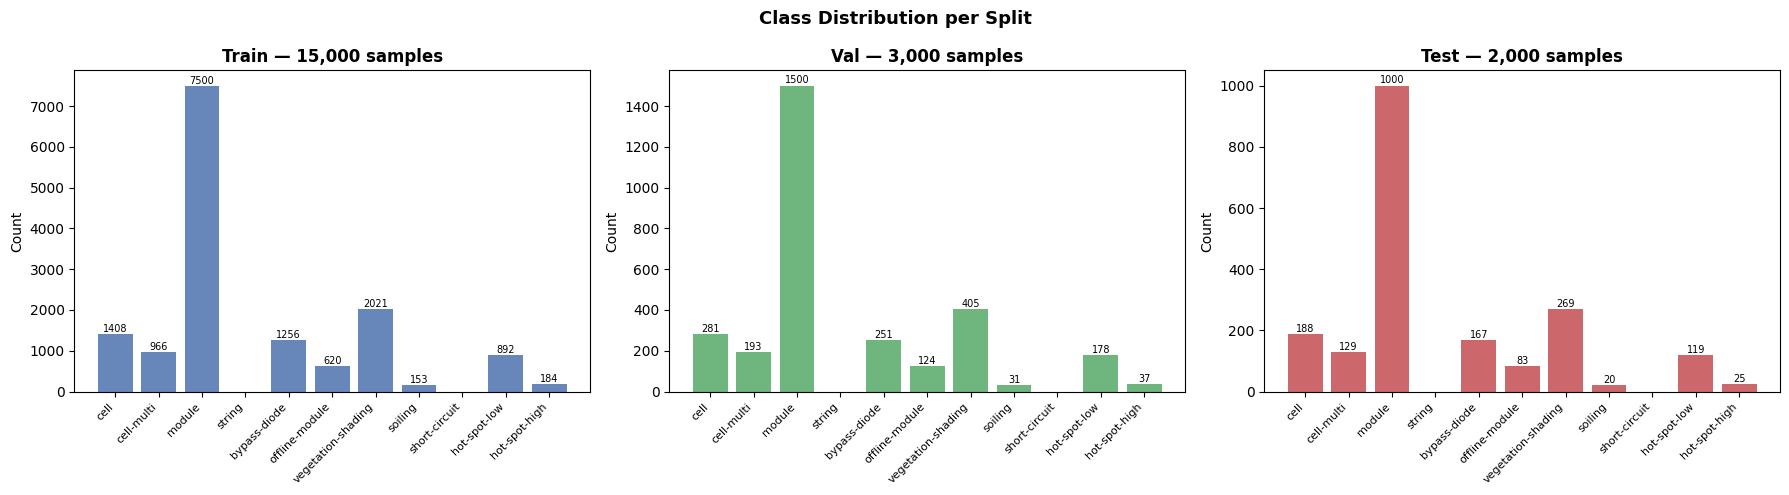

In [9]:
def count_classes_in_split(split: str) -> list:
    counts = [0] * len(CANONICAL_CLASSES)
    for p in (DATA_DIR / "labels" / split).glob("*.txt"):
        for line in p.read_text().splitlines():
            parts = line.strip().split()
            if parts:
                cid = int(parts[0])
                if 0 <= cid < len(counts):
                    counts[cid] += 1
    return counts

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, split, color in zip(axes, ["train", "val", "test"], ["#4C72B0", "#55A868", "#C44E52"]):
    counts = count_classes_in_split(split)
    bars = ax.bar(range(len(CANONICAL_CLASSES)), counts, color=color, alpha=0.85)
    ax.set_xticks(range(len(CANONICAL_CLASSES)))
    ax.set_xticklabels(CANONICAL_CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{split.capitalize()} — {sum(counts):,} samples", fontweight="bold")
    ax.set_ylabel("Count")
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(cnt), ha="center", va="bottom", fontsize=7)
plt.suptitle("Class Distribution per Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Sample Image Grid — 9 Training Images with Bounding Boxes

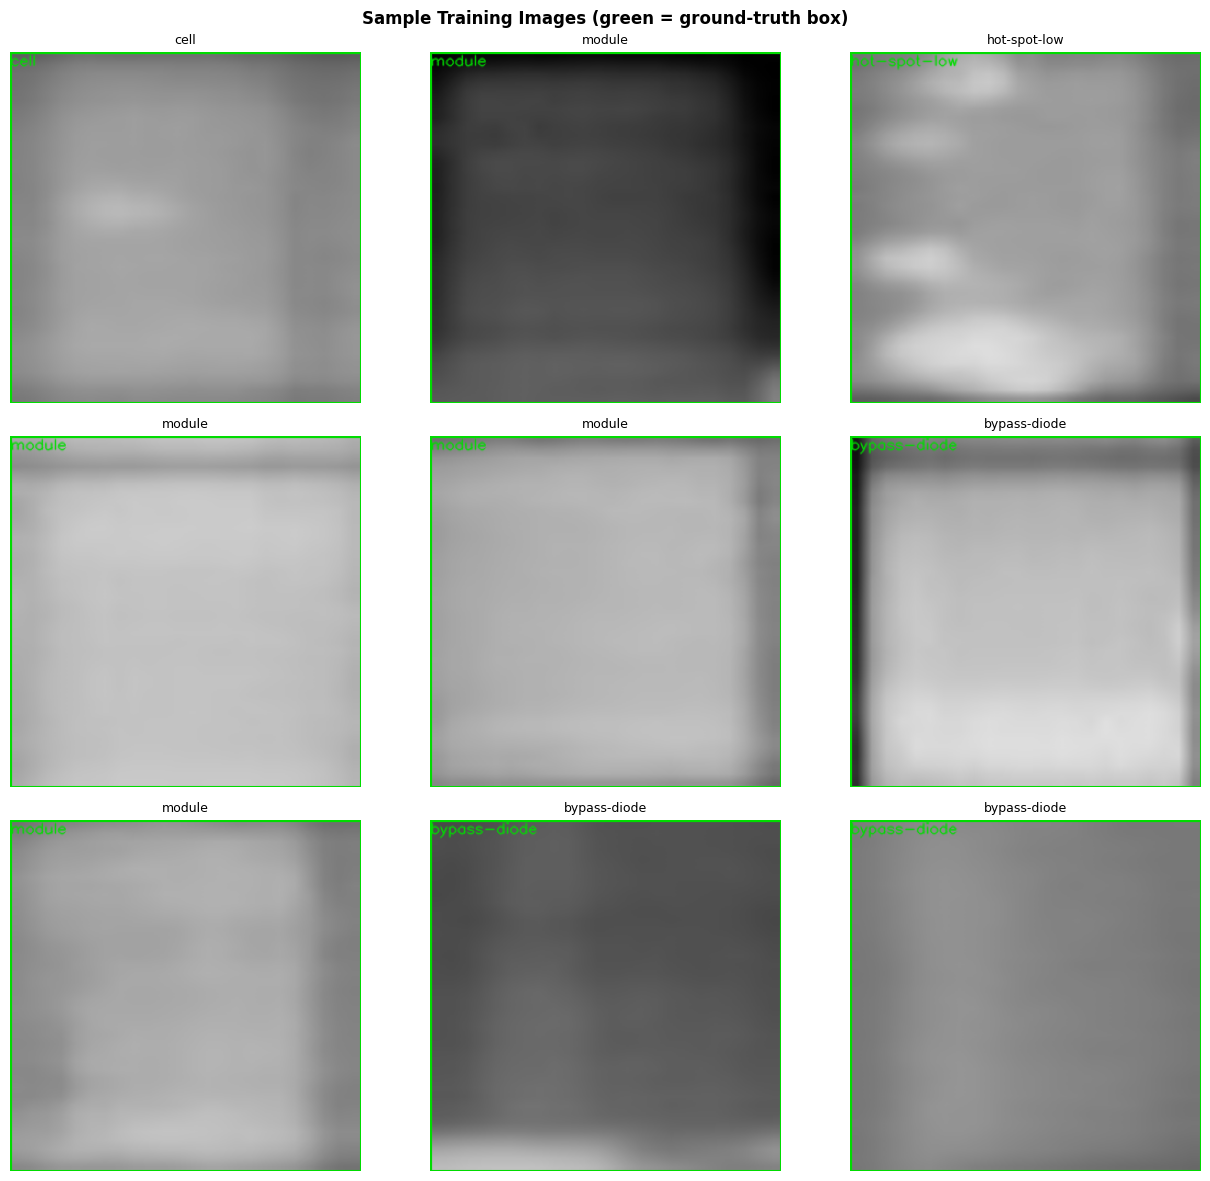

In [10]:
def draw_yolo_boxes(img_bgr, boxes, color=(0,255,0), labels=None, font_scale=0.45):
    out = img_bgr.copy()
    h, w = out.shape[:2]
    for row in boxes:
        cid, cx, cy, bw, bh = int(row[0]), *map(float, row[1:])
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        cv2.rectangle(out, (x1,y1), (x2,y2), color, 2)
        if labels and 0 <= cid < len(labels):
            cv2.putText(out, labels[cid], (x1, max(y1-4,12)),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 1, cv2.LINE_AA)
    return out

train_imgs = sorted((DATA_DIR / "images" / "train").glob("*.jpg"))
rng = np.random.RandomState(SEED)
picked = rng.choice(train_imgs, size=min(9, len(train_imgs)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for ax, img_path in zip(axes.flatten(), picked):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (320, 320))
    lbl_path = DATA_DIR / "labels" / "train" / (img_path.stem + ".txt")
    boxes = [line.split() for line in lbl_path.read_text().splitlines() if line.strip()]
    img_ann = draw_yolo_boxes(img, boxes, color=(0,220,0), labels=CANONICAL_CLASSES)
    ax.imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    class_name = CANONICAL_CLASSES[int(boxes[0][0])] if boxes else "?"
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Training Images (green = ground-truth box)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Offline Augmentation (2× Training Set)

Albumentations pipeline applied once per training image.
Set `RUN_AUGMENTATION = False` in CONFIG to skip.

**Pipeline:** HorizontalFlip · VerticalFlip · RandomRotate90 · ShiftScaleRotate · Perspective · RandomBrightnessContrast · GaussNoise · GaussianBlur · RandomGamma · CLAHE · CoarseDropout → Resize(640×640)

`hsv_h=0, hsv_s=0` — thermal images carry no meaningful hue/saturation.

In [11]:
AUG_DIR = DATA_DIR / "augmented"

if RUN_AUGMENTATION:
    pipeline = A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.6),
            A.Perspective(scale=(0.04, 0.08), p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
            A.GaussianBlur(blur_limit=(3, 5), p=0.3),
            A.RandomGamma(gamma_limit=(80, 120), p=0.4),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
            A.CoarseDropout(num_holes_range=(4, 8),
                            hole_height_range=(8, 32),
                            hole_width_range=(8, 32), fill=0, p=0.3),
            A.Resize(IMGSZ, IMGSZ),
        ],
        bbox_params=A.BboxParams(
            format="yolo", label_fields=["class_labels"],
            min_visibility=0.3, clip=True,
        ),
    )

    src_imgs = DATA_DIR / "images" / "train"
    src_lbls = DATA_DIR / "labels" / "train"
    aug_imgs = AUG_DIR / "images" / "train"
    aug_lbls = AUG_DIR / "labels" / "train"
    aug_imgs.mkdir(parents=True, exist_ok=True)
    aug_lbls.mkdir(parents=True, exist_ok=True)

    written = 0
    for img_path in tqdm(sorted(src_imgs.glob("*.jpg")), desc="Augmenting"):
        lbl_path = src_lbls / (img_path.stem + ".txt")
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        raw_boxes = [line.split() for line in lbl_path.read_text().splitlines() if line.strip()]
        bboxes      = [(float(r[1]), float(r[2]), float(r[3]), float(r[4])) for r in raw_boxes]
        class_ids   = [int(r[0]) for r in raw_boxes]

        # Copy original
        shutil.copy2(img_path, aug_imgs / img_path.name)
        shutil.copy2(lbl_path, aug_lbls / lbl_path.name)
        written += 1

        # One augmented copy
        res = pipeline(image=img, bboxes=bboxes, class_labels=class_ids)
        aug_boxes = [
            f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
            for cid, (cx, cy, w, h) in zip(res["class_labels"], res["bboxes"])
        ]
        stem = img_path.stem + "_aug"
        cv2.imwrite(str(aug_imgs / (stem + ".jpg")), res["image"])
        (aug_lbls / (stem + ".txt")).write_text("\n".join(aug_boxes) + "\n")
        written += 1

    # Copy val and test unchanged
    for split in ("val", "test"):
        for kind in ("images", "labels"):
            src = DATA_DIR / kind / split
            dst = AUG_DIR / kind / split
            if src.exists() and not dst.exists():
                shutil.copytree(src, dst)

    print(f"Augmented train set: {written} images total")
else:
    print("Skipping augmentation — using original data.")
    AUG_DIR = DATA_DIR

TRAIN_YAML = AUG_DIR / "thermal_dataset.yaml"
with TRAIN_YAML.open("w") as f:
    yaml.dump({
        "path":  str(AUG_DIR.resolve()),
        "train": "images/train",
        "val":   "images/val",
        "test":  "images/test",
        "nc":    len(CANONICAL_CLASSES),
        "names": CANONICAL_CLASSES,
    }, f, default_flow_style=False)
print(f"Training YAML: {TRAIN_YAML}")

Augmenting:   0%|          | 0/15000 [00:00<?, ?it/s]

Augmented train set: 30000 images total
Training YAML: /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/augmented/thermal_dataset.yaml


## 10. Train YOLOv8s

Key thermal overrides:
- `hsv_h=0, hsv_s=0` — no hue/saturation shift on thermal images
- `cos_lr=True` + `warmup_epochs=3`
- `close_mosaic=10` — stabilises final epochs

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=str(TRAIN_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    lr0=0.01,
    lrf=0.001,
    cos_lr=True,
    warmup_epochs=3,
    patience=PATIENCE,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    close_mosaic=10,
    seed=SEED,
    project=str(WORK_DIR / "runs" / "thermal"),
    name="train",
    exist_ok=True,
    save_period=10,
    verbose=True,
)
print("Training complete.")

Ultralytics 8.4.33 🚀 Python-3.13.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 3771MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/augmented/thermal_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opse

In [5]:
import os
from pathlib import Path

# Try one level up
WORK_DIR = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection")

RUN_DIR = WORK_DIR / "runs" / "thermal" / "train"
weights_dir = RUN_DIR / "weights"

print("Path:", weights_dir)
print("Exists:", weights_dir.exists())
print("Files:", list(weights_dir.glob("*.pt")))

Path: /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights
Exists: True
Files: [PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/best.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch50.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch0.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch20.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch30.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch40.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/last.pt'), PosixPath('/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/epoch10.pt')]


In [10]:
from ultralytics import YOLO

WORK_DIR = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection")
RUN_DIR = WORK_DIR / "runs" / "thermal" / "train"
weights_dir = RUN_DIR / "weights"

# Resume from last.pt (continues from epoch 53)
model = YOLO(str(weights_dir / "last.pt"))
model.train(resume=True)


WARNING ⚠️ model '/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.33 🚀 Python-3.13.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 3771MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a47b02a0980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

## 11. Save Best Checkpoint

In [11]:
import shutil
from pathlib import Path

WORK_DIR = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection")
CHECKPT_BEST = WORK_DIR / "checkpoints" / "best.pt"
CHECKPT_DIR = WORK_DIR / "checkpoints"

RUN_DIR  = WORK_DIR / "runs" / "thermal" / "train"
best_src = RUN_DIR / "weights" / "best.pt"

CHECKPT_DIR.mkdir(parents=True, exist_ok=True)
if best_src.exists():
    shutil.copy2(best_src, CHECKPT_BEST)
    print(f"Best checkpoint → {CHECKPT_BEST}")
else:
    pts = list((RUN_DIR / "weights").glob("*.pt")) if (RUN_DIR / "weights").exists() else []
    print("Available:", pts)

Best checkpoint → /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/checkpoints/best.pt


## 12. Training Loss & mAP Curves

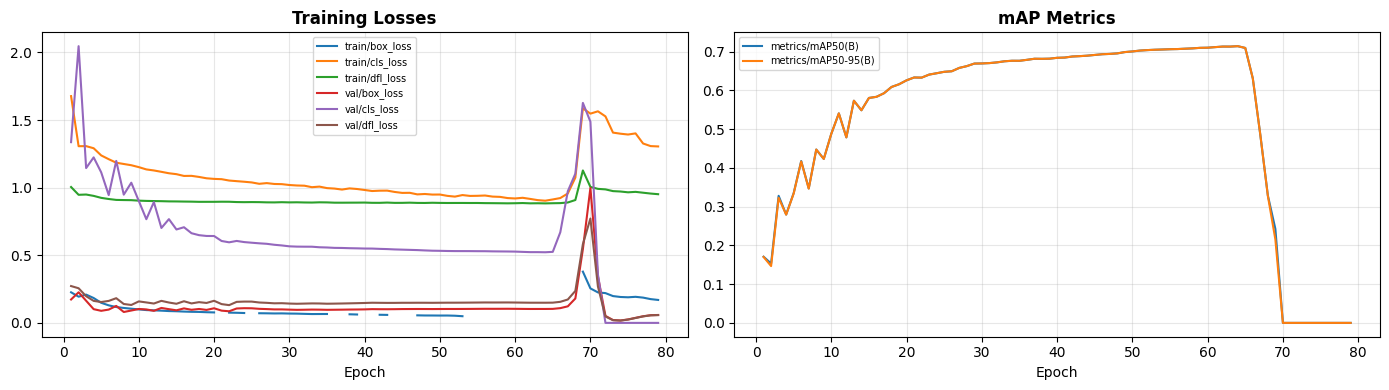

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR / "results.csv"
if results_csv.exists():
    df_train = pd.read_csv(results_csv)
    df_train.columns = df_train.columns.str.strip()
    epoch_col = [c for c in df_train.columns if "epoch" in c.lower()][0]

    loss_cols = [c for c in df_train.columns if "loss" in c.lower()]
    map_cols  = [c for c in df_train.columns if "map"  in c.lower()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    for col in loss_cols:
        ax1.plot(df_train[epoch_col], df_train[col], label=col.strip())
    ax1.set_title("Training Losses", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

    for col in map_cols:
        ax2.plot(df_train[epoch_col], df_train[col], label=col.strip())
    ax2.set_title("mAP Metrics", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print(f"results.csv not found at {results_csv}")

In [13]:
import os
# Find all yaml files in the project
for root, dirs, files in os.walk(WORK_DIR):
    for f in files:
        if f.endswith(".yaml") or f.endswith(".yml"):
            print(os.path.join(root, f))

/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/thermal_dataset.yaml
/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/augmented/thermal_dataset.yaml
/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/configs/thermal.yaml
/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/runs/thermal/train/args.yaml


In [16]:
import yaml
import shutil, pandas as pd, matplotlib.pyplot as plt, os, yaml
from pathlib import Path
from ultralytics import YOLO
WORK_DIR      = Path("/home/parakh/Desktop/AxalonPIPE/solar_thermal_detection")
CHECKPT_BEST  = WORK_DIR / "checkpoints" / "best.pt"
CHECKPT_DIR   = WORK_DIR / "checkpoints"
DATASET_YAML  = WORK_DIR / "data" / "thermal_dataset.yaml"
CONF_THRESH   = 0.25
IOU_THRESH    = 0.45
DEVICE        = "cuda"
with open(DATASET_YAML) as f:
    _yaml = yaml.safe_load(f)

CANONICAL_CLASSES = _yaml["names"]  # list of class names from your yaml
print(CANONICAL_CLASSES)

['cell', 'cell-multi', 'module', 'string', 'bypass-diode', 'offline-module', 'vegetation-shading', 'soiling', 'short-circuit', 'hot-spot-low', 'hot-spot-high']


## 13. Evaluation — Per-Class AP50 / AP50-95

In [18]:
from ultralytics import YOLO
import numpy as np

# ── Constants ──────────────────────────────────────────────────────────
DATASET_YAML  = WORK_DIR / "data" / "thermal_dataset.yaml"
CONF_THRESH   = 0.25
IOU_THRESH    = 0.45
DEVICE        = "cuda"

CANONICAL_CLASSES = ['cell', 'cell-multi', 'module', 'string', 'bypass-diode', 
                     'offline-module', 'vegetation-shading', 'soiling', 
                     'short-circuit', 'hot-spot-low', 'hot-spot-high']

# ── Evaluation ─────────────────────────────────────────────────────────
eval_model = YOLO(str(CHECKPT_BEST))
metrics    = eval_model.val(
    data=str(DATASET_YAML), split="test",
    conf=CONF_THRESH, iou=IOU_THRESH,
    device=DEVICE, verbose=False, plots=False,
)

ap50    = np.array(metrics.box.ap50).flatten()
ap50_95 = np.array(metrics.box.ap).flatten()

# Match lengths safely
n       = min(len(ap50), len(ap50_95), len(CANONICAL_CLASSES))
classes = CANONICAL_CLASSES[:n]

df_ap = pd.DataFrame({
    "Class":    classes,
    "AP@50":    ap50[:n].tolist(),
    "AP@50:95": ap50_95[:n].tolist(),
}).sort_values("AP@50", ascending=False).reset_index(drop=True)

print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50:95 : {metrics.box.map:.4f}\n")
display(df_ap.style.format({"AP@50": "{:.4f}", "AP@50:95": "{:.4f}"})
              .background_gradient(subset=["AP@50","AP@50:95"], cmap="YlGn"))

Ultralytics 8.4.33 🚀 Python-3.13.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 3771MiB)
Model summary (fused): 73 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.5±1.4 MB/s, size: 0.5 KB)
val: Scanning /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/labels/test.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 645.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.8it/s 21.7s0.2s
                   all       2000       2000      0.734      0.687      0.728      0.728
Speed: 0.3ms preprocess, 9.6ms inference, 0.0ms loss, 0.3ms postprocess per image
mAP50    : 0.7283
mAP50:95 : 0.7283



,Class,AP@50,AP@50:95
0,string,0.9920,0.9920
1,module,0.9770,0.9770
2,offline-module,0.7735,0.7735
3,soiling,0.7587,0.7587
4,cell,0.7523,0.7523
5,bypass-diode,0.6691,0.6691
6,short-circuit,0.6043,0.6043
7,cell-multi,0.5806,0.5806
8,vegetation-shading,0.4471,0.4471


## 14. Confusion Matrix

Ultralytics 8.4.33 🚀 Python-3.13.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 3771MiB)
Model summary (fused): 73 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6.7±1.4 MB/s, size: 0.6 KB)
val: Scanning /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/data/labels/test.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.5it/s 22.6s0.2s
                   all       2000       2000      0.734      0.687      0.728      0.728
Speed: 0.4ms preprocess, 9.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/parakh/runs/detect/val6


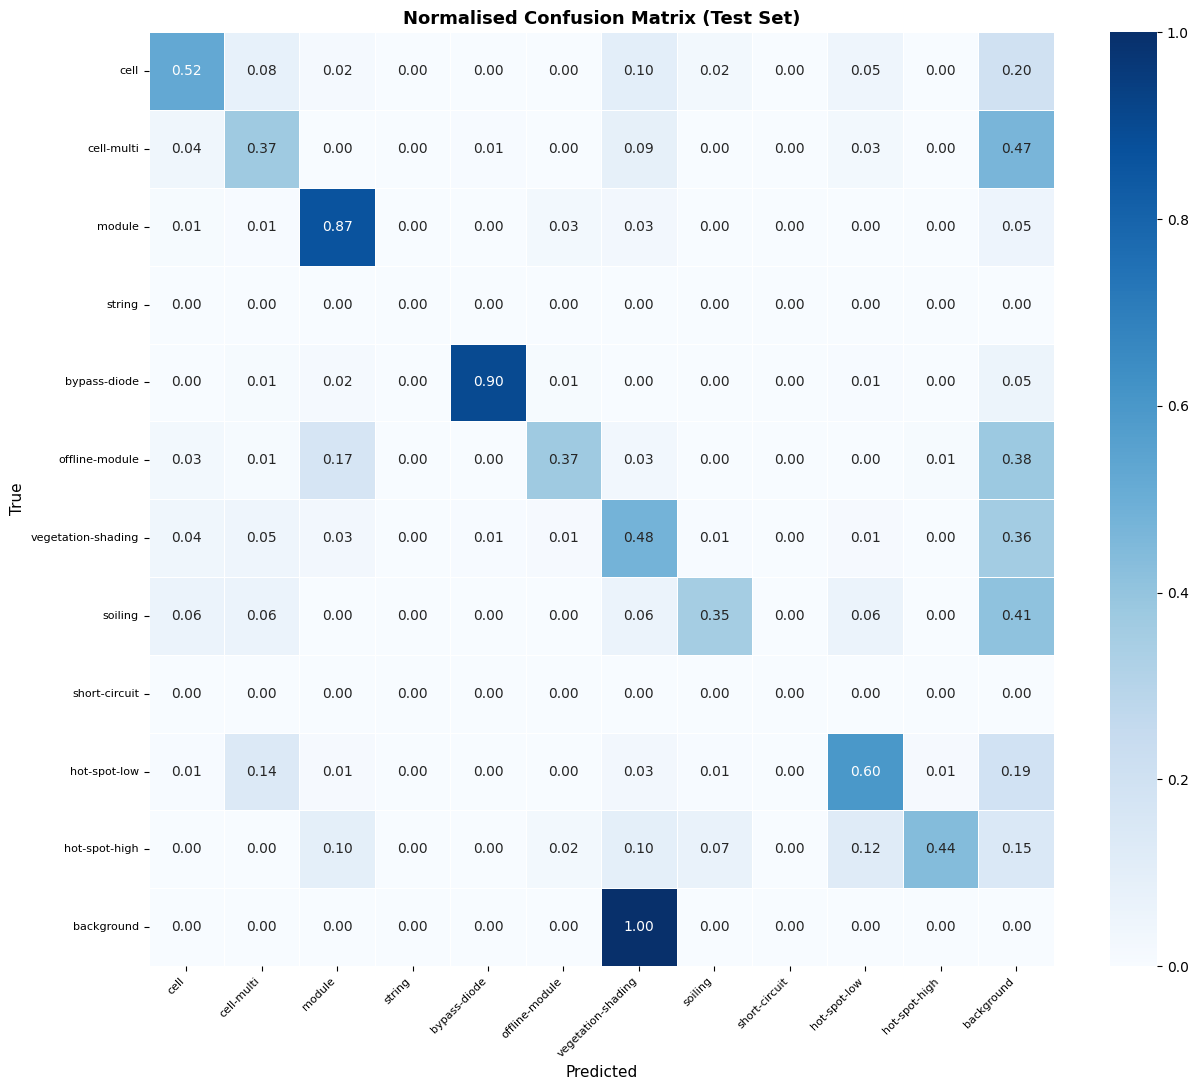

In [20]:
# Re-run val with plots=True to populate confusion matrix
cm_model   = YOLO(str(CHECKPT_BEST))
cm_metrics = cm_model.val(
    data=str(DATASET_YAML), split="test",
    conf=CONF_THRESH, iou=IOU_THRESH,
    device=DEVICE, verbose=False, plots=True,
)

cm_obj = cm_metrics.confusion_matrix
if cm_obj is None or cm_obj.matrix is None:
    print("Confusion matrix not available")
else:
    cm = cm_obj.matrix.astype(float)
    n  = cm.shape[0]
    labels_bg = CANONICAL_CLASSES[:n-1] + ["background"] if n > len(CANONICAL_CLASSES) else CANONICAL_CLASSES
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=labels_bg, yticklabels=labels_bg,
                cmap="Blues", linewidths=0.4, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title("Normalised Confusion Matrix (Test Set)", fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0,  fontsize=8)
    plt.tight_layout(); plt.show()

## 15. PR Curves per Class

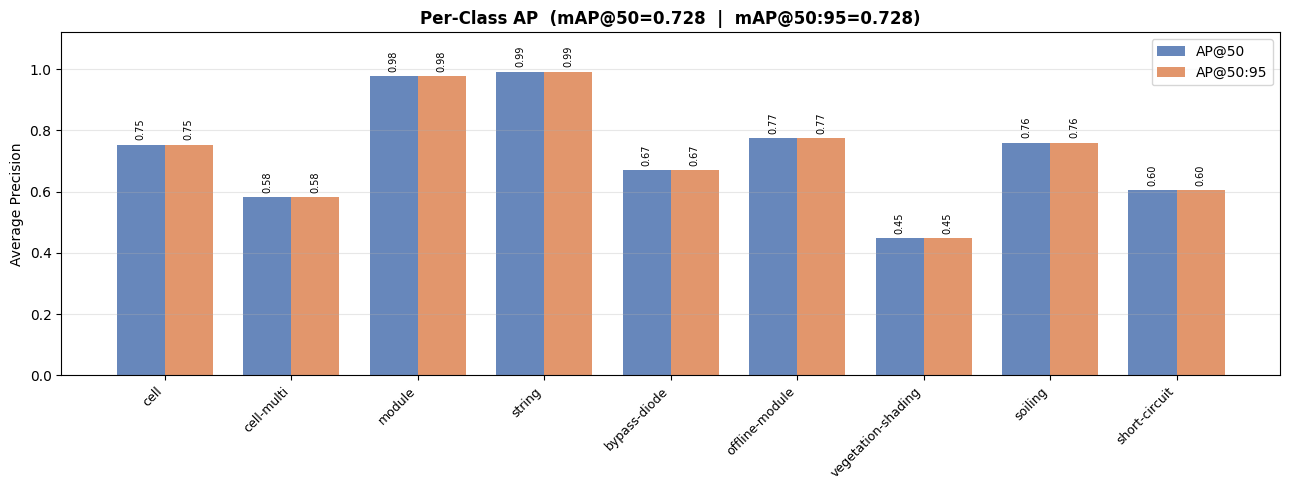

In [22]:
n_classes    = min(len(CANONICAL_CLASSES), len(ap50), len(ap50_95))
classes_plot = CANONICAL_CLASSES[:n_classes]
ap50_vals    = np.array(ap50.tolist())[:n_classes]
ap5095_vals  = np.array(ap50_95.tolist())[:n_classes]

x = np.arange(n_classes)
w = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - w/2, ap50_vals,   w, label="AP@50",    color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + w/2, ap5095_vals, w, label="AP@50:95", color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Average Precision")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.set_title(
    f"Per-Class AP  (mAP@50={cm_metrics.box.map50:.3f}  |  mAP@50:95={cm_metrics.box.map:.3f})",
    fontsize=12, fontweight="bold"
)
ax.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)

plt.tight_layout(); plt.show()

## 16. Inference Grid — 12 Test Images: GT (green) vs Predicted (red)

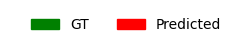

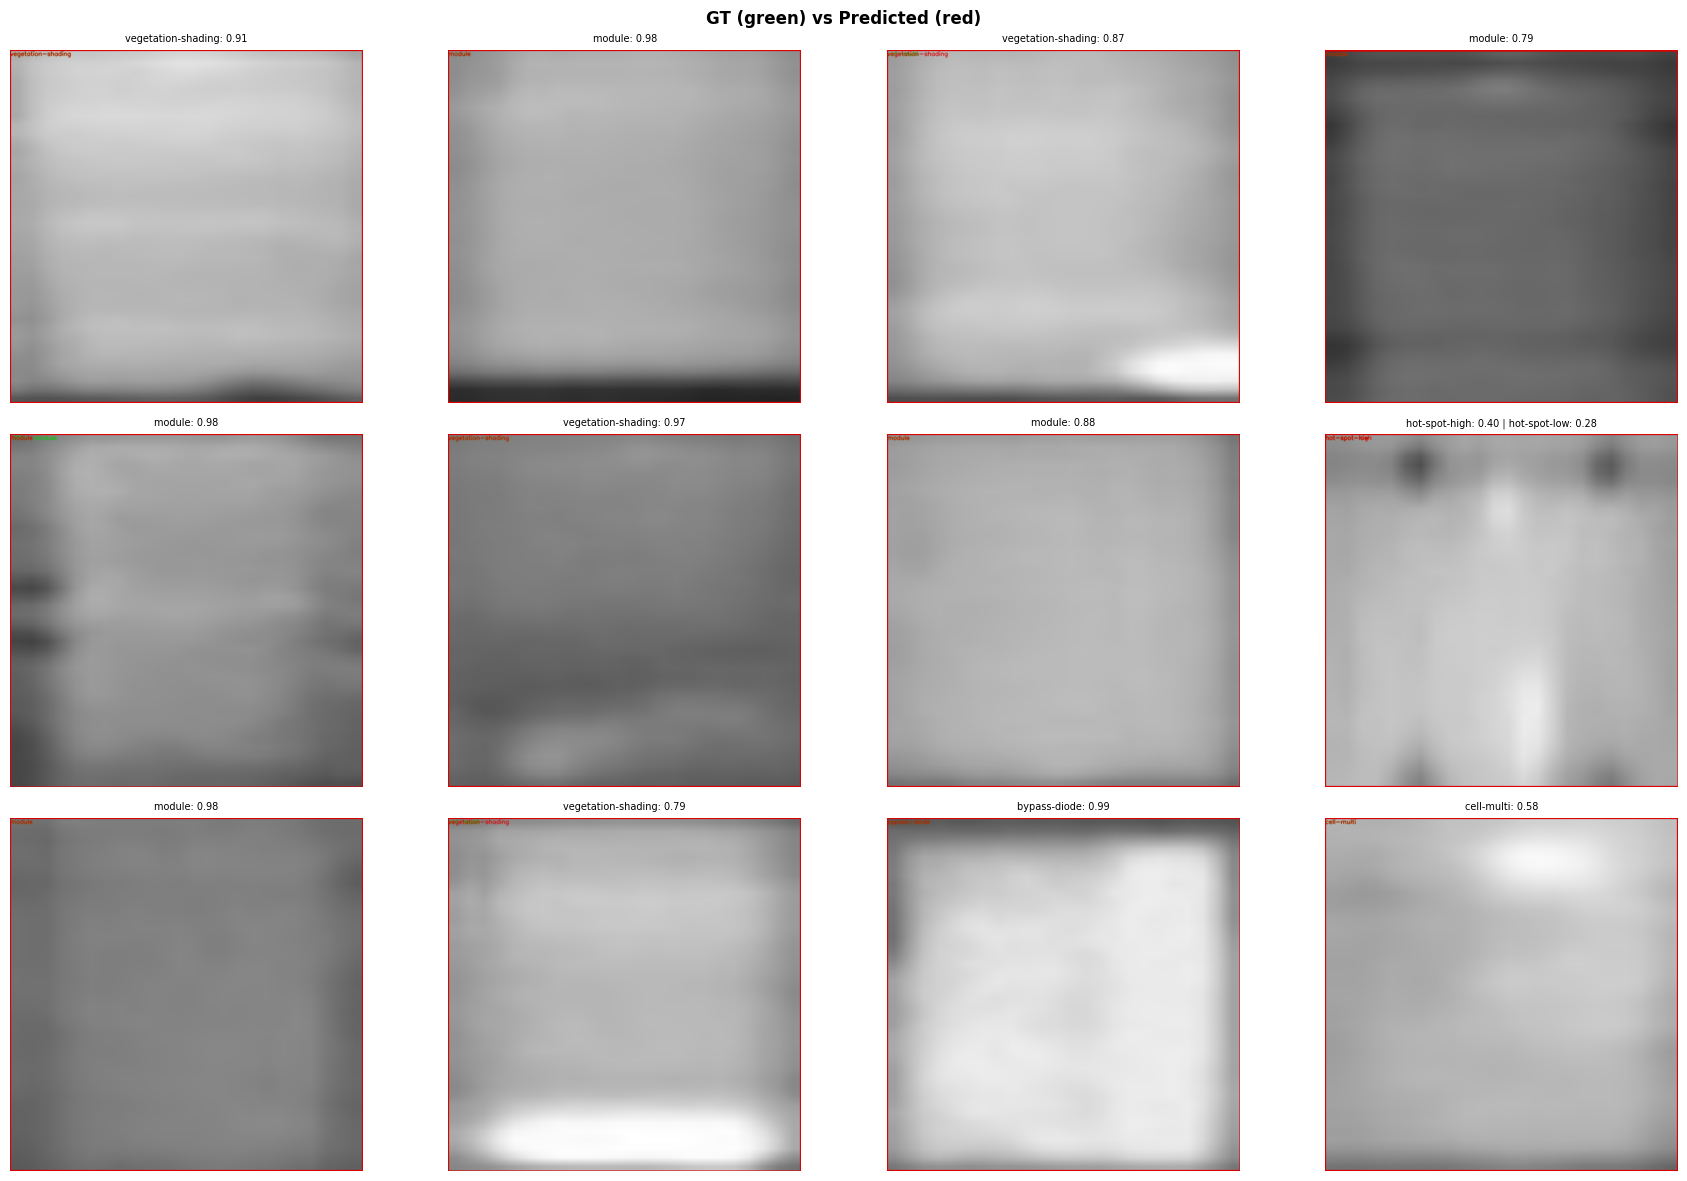

In [26]:
import cv2
import matplotlib.patches as mpatches

# ── Missing constants ───────────────────────────────────────────────────
AUG_DIR = WORK_DIR / "data" / "augmented"
SEED    = 42
IMGSZ   = 640

# ── Helper function ─────────────────────────────────────────────────────
def draw_yolo_boxes(img, rows, color, labels, font_scale=0.4):
    h, w = img.shape[:2]
    for row in rows:
        if len(row) < 5:
            continue
        cls_id = int(row[0])
        cx, cy, bw, bh = float(row[1]), float(row[2]), float(row[3]), float(row[4])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = labels[cls_id] if cls_id < len(labels) else str(cls_id)
        cv2.putText(img, label, (x1, max(y1-4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 1, cv2.LINE_AA)
    return img

# ── Main ────────────────────────────────────────────────────────────────
test_imgs_dir = AUG_DIR / "images" / "test"
test_lbls_dir = AUG_DIR / "labels" / "test"

all_test = sorted(test_imgs_dir.glob("*.jpg"))
rng      = np.random.RandomState(SEED)
picked12 = rng.choice(all_test, size=min(12, len(all_test)), replace=False)

inf_model = YOLO(str(CHECKPT_BEST))
rendered  = []
titles    = []

for img_path in picked12:
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (IMGSZ, IMGSZ))

    lbl_path = test_lbls_dir / (img_path.stem + ".txt")
    gt_rows  = [line.split() for line in lbl_path.read_text().splitlines() if line.strip()]
    img      = draw_yolo_boxes(img, gt_rows, color=(0,200,0), labels=CANONICAL_CLASSES, font_scale=0.36)

    preds = inf_model.predict(img_path, conf=CONF_THRESH, iou=IOU_THRESH,
                               device=DEVICE, verbose=False)[0]
    pred_rows = [
        [int(b.cls.item()), *b.xywhn[0].tolist()]
        for b in preds.boxes
    ]
    img = draw_yolo_boxes(img, pred_rows, color=(0,0,220), labels=CANONICAL_CLASSES, font_scale=0.36)

    conf_str = " | ".join(
        f"{CANONICAL_CLASSES[int(b.cls.item())]}: {float(b.conf.item()):.2f}"
        for b in preds.boxes[:2]
    ) or "(no prediction)"
    rendered.append(img)
    titles.append(conf_str)

# Legend
fig_l, ax_l = plt.subplots(figsize=(3, 0.4))
ax_l.legend(
    handles=[mpatches.Patch(color='green', label='GT'),
             mpatches.Patch(color='red',   label='Predicted')],
    loc='center', ncol=2, frameon=False, fontsize=10
)
ax_l.axis('off'); plt.show()

# Grid
ncols = 4
nrows = (len(rendered) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4*nrows))
for ax, img_bgr, title in zip(axes.flatten(), rendered, titles):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=7)
    ax.axis('off')
for ax in axes.flatten()[len(rendered):]:
    ax.set_visible(False)
plt.suptitle("GT (green) vs Predicted (red)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 17. Run Inference & Build Inspection Report

In [27]:
# Ensure inference model is loaded (in case section 16 was skipped)
if 'inf_model' not in dir():
    inf_model = YOLO(str(CHECKPT_BEST))

INFER_DIR = AUG_DIR / "images" / INFER_SPLIT
ANNOT_DIR = OUTPUT_DIR / "annotated"
ANNOT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

img_paths = sorted(
    p for p in INFER_DIR.iterdir()
    if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"}
)
print(f"Inferring on {len(img_paths)} images from '{INFER_SPLIT}' split …")

all_detections: list[dict] = []

for img_path in tqdm(img_paths, desc="Inference"):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue

    preds = inf_model.predict(
        img_path, conf=CONF_THRESH, iou=IOU_THRESH,
        imgsz=IMGSZ, device=DEVICE, verbose=False
    )[0]

    dets_this: list[dict] = []
    for box in preds.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cid  = int(box.cls.item())
        conf = float(box.conf.item())
        cls_name = CANONICAL_CLASSES[cid] if cid < len(CANONICAL_CLASSES) else f"class_{cid}"
        severity = SEVERITY_MAP.get(cls_name, "MEDIUM")
        det = {
            "image_file": img_path.name,
            "bbox":       [round(x1,1), round(y1,1), round(x2,1), round(y2,1)],
            "class":      cls_name,
            "confidence": round(conf, 4),
            "severity":   severity,
        }
        all_detections.append(det)
        dets_this.append(det)

    # Draw severity-coded boxes and save
    ann = img_bgr.copy()
    for d in dets_this:
        x1,y1,x2,y2 = [int(v) for v in d["bbox"]]
        color = SEV_COLOR_BGR.get(d["severity"], (128,128,128))
        cv2.rectangle(ann, (x1,y1), (x2,y2), color, 2)
        cv2.putText(ann, f"{d['class']} {d['confidence']:.2f}",
                    (x1, max(y1-4,12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)
    cv2.imwrite(str(ANNOT_DIR / img_path.name), ann)

print(f"Total detections: {len(all_detections)}")

Inferring on 2000 images from 'test' split …


Inference:   0%|          | 0/2000 [00:00<?, ?it/s]

Total detections: 2236


## 18. Save results.csv & inspection_report.json

In [28]:
# ── results.csv ───────────────────────────────────────────────────────────────
RESULTS_CSV = OUTPUT_DIR / "results.csv"
if all_detections:
    df_res = pd.DataFrame(all_detections)
    df_res[["x1","y1","x2","y2"]] = pd.DataFrame(df_res["bbox"].tolist(), index=df_res.index)
    df_res = df_res.drop(columns=["bbox"])[["image_file","class","severity","confidence","x1","y1","x2","y2"]]
    df_res.to_csv(RESULTS_CSV, index=False)
    print(f"results.csv → {RESULTS_CSV}  ({len(df_res)} rows)")
    display(df_res.head(8))
else:
    print("No detections — results.csv not written.")

# ── inspection_report.json ────────────────────────────────────────────────────
REPORT_JSON = OUTPUT_DIR / "inspection_report.json"
SEV_LEVELS  = ["CRITICAL","HIGH","MEDIUM","LOW"]

per_image: dict[str, list] = defaultdict(list)
for d in all_detections:
    per_image[d["image_file"]].append(d)

image_summaries = []
for ip in img_paths:
    dets = per_image.get(ip.name, [])
    sev_counts = {s: sum(1 for d in dets if d["severity"]==s) for s in SEV_LEVELS}
    cls_counts = dict(Counter(d["class"] for d in dets))
    image_summaries.append({
        "image_file":       ip.name,
        "total_detections": len(dets),
        "severity_counts":  sev_counts,
        "class_counts":     cls_counts,
        "has_critical":     sev_counts["CRITICAL"] > 0,
    })

report = {
    "summary": {
        "total_images_inspected": len(img_paths),
        "total_detections":       len(all_detections),
        "images_with_critical":   sum(1 for s in image_summaries if s["has_critical"]),
        "severity_totals":        {s: sum(im["severity_counts"][s] for im in image_summaries) for s in SEV_LEVELS},
    },
    "images": image_summaries,
}
with REPORT_JSON.open("w") as f:
    json.dump(report, f, indent=2)
print(f"inspection_report.json → {REPORT_JSON}")
print(json.dumps(report["summary"], indent=2))

results.csv → /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/output/results.csv  (2236 rows)


,image_file,class,severity,confidence,x1,y1,x2,y2
0,10002.jpg,module,MEDIUM,0.9748,0.0,0.0,24.0,40.0
1,10014.jpg,vegetation-shading,LOW,0.9519,0.0,0.0,24.0,40.0
2,10024.jpg,module,MEDIUM,0.9775,0.0,0.0,24.0,40.0
3,1003.jpg,bypass-diode,CRITICAL,0.9925,0.0,0.0,24.0,39.9
4,10054.jpg,module,MEDIUM,0.9931,0.0,0.0,24.0,40.0
5,10056.jpg,module,MEDIUM,0.9749,0.0,0.0,24.0,40.0
6,10062.jpg,module,MEDIUM,0.9635,0.0,0.0,24.0,40.0
7,10083.jpg,module,MEDIUM,0.9864,0.0,0.0,24.0,40.0


inspection_report.json → /home/parakh/Desktop/AxalonPIPE/solar_thermal_detection/output/inspection_report.json
{
  "total_images_inspected": 2000,
  "total_detections": 2236,
  "images_with_critical": 222,
  "severity_totals": {
    "CRITICAL": 222,
    "HIGH": 233,
    "MEDIUM": 1444,
    "LOW": 337
  }
}


## 19. Summary Dashboard

In [ ]:
if not all_detections:
    print("No detections — nothing to plot.")
else:
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle("Inspection Summary Dashboard", fontsize=14, fontweight="bold", y=1.01)
    summary = report["summary"]

    # ── KPI box ───────────────────────────────────────────────────────────
    ax0 = fig.add_subplot(1, 3, 1)
    ax0.axis("off")
    kpi = [
        f"Panels inspected : {summary['total_images_inspected']}",
        f"Total detections : {summary['total_detections']}",
        f"Critical images  : {summary['images_with_critical']}",
        "",
    ] + [f"{s:<10s}: {summary['severity_totals'][s]:>5d}" for s in SEV_LEVELS]
    ax0.text(0.05, 0.95, "\n".join(kpi), transform=ax0.transAxes,
             va="top", fontsize=11, fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
    ax0.set_title("Key Metrics", fontweight="bold")

    # ── Detections per class (bar) ────────────────────────────────────────
    ax1 = fig.add_subplot(1, 3, 2)
    cls_totals = Counter(d["class"] for d in all_detections)
    sorted_cls = sorted(cls_totals, key=lambda c: -cls_totals[c])
    counts     = [cls_totals[c] for c in sorted_cls]
    bars = ax1.bar(range(len(sorted_cls)), counts, color="#4C72B0", alpha=0.85)
    ax1.set_xticks(range(len(sorted_cls)))
    ax1.set_xticklabels(sorted_cls, rotation=45, ha="right", fontsize=8)
    ax1.set_ylabel("Detection count")
    ax1.set_title("Detections per Class", fontweight="bold")
    for bar, cnt in zip(bars, counts):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 str(cnt), ha="center", va="bottom", fontsize=8)
    ax1.grid(axis="y", alpha=0.3)

    # ── Severity pie ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(1, 3, 3)
    sev_vals   = {s: summary["severity_totals"][s] for s in SEV_LEVELS if summary["severity_totals"][s] > 0}
    sev_colors = {"CRITICAL":"#e74c3c","HIGH":"#e67e22","MEDIUM":"#f1c40f","LOW":"#3498db"}
    ax2.pie(list(sev_vals.values()), labels=list(sev_vals.keys()),
            colors=[sev_colors[s] for s in sev_vals],
            autopct="%1.1f%%", startangle=140, textprops={"fontsize":9})
    ax2.set_title("Severity Breakdown", fontweight="bold")

    plt.tight_layout(); plt.show()

NameError: name 'all_detections' is not defined